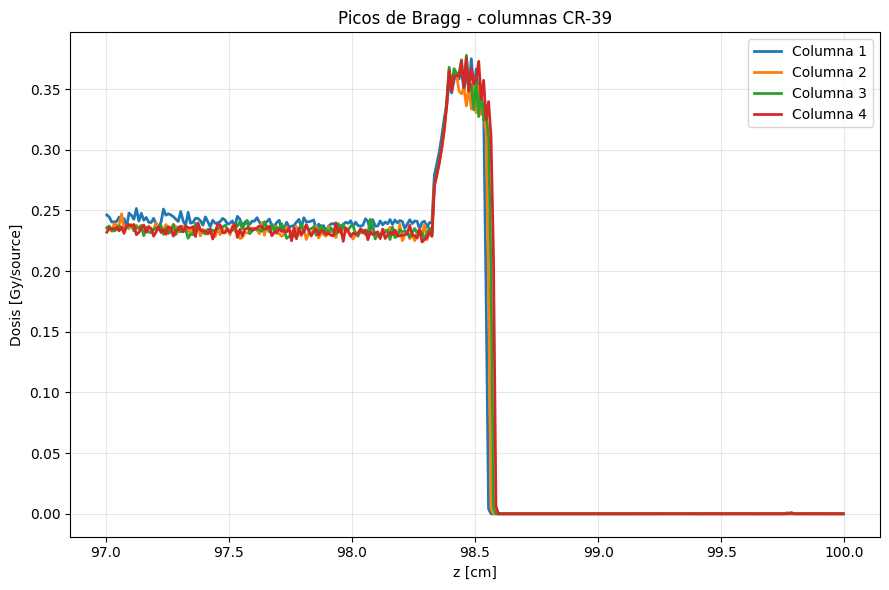

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

archivos = {
    "Columna 1": "../out/bragg_CR39_col1.out",
    "Columna 2": "../out/bragg_CR39_col2.out",
    "Columna 3": "../out/bragg_CR39_col3.out",
    "Columna 4": "../out/bragg_CR39_col4.out",
}

def leer_phits(ruta):
    z = []
    dosis = []

    with open(ruta, "r") as f:
        for linea in f:
            datos = linea.split()

            if len(datos) >= 4:
                try:
                    z_lower = float(datos[0])
                    z_upper = float(datos[1])
                    dose = float(datos[2])

                    if 97 <= z_lower <= 100 and 97 <= z_upper <= 100:
                        z.append((z_lower + z_upper) / 2)
                        dosis.append(dose)

                except ValueError:
                    pass

    return np.array(z), np.array(dosis)


plt.figure(figsize=(9, 6))

for nombre, archivo in archivos.items():
    z, dosis = leer_phits(archivo)
    plt.plot(z, dosis, label=nombre, linewidth=2)

plt.xlabel("z [cm]")
plt.ylabel("Dosis [Gy/source]")
plt.title("Picos de Bragg - columnas CR-39")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

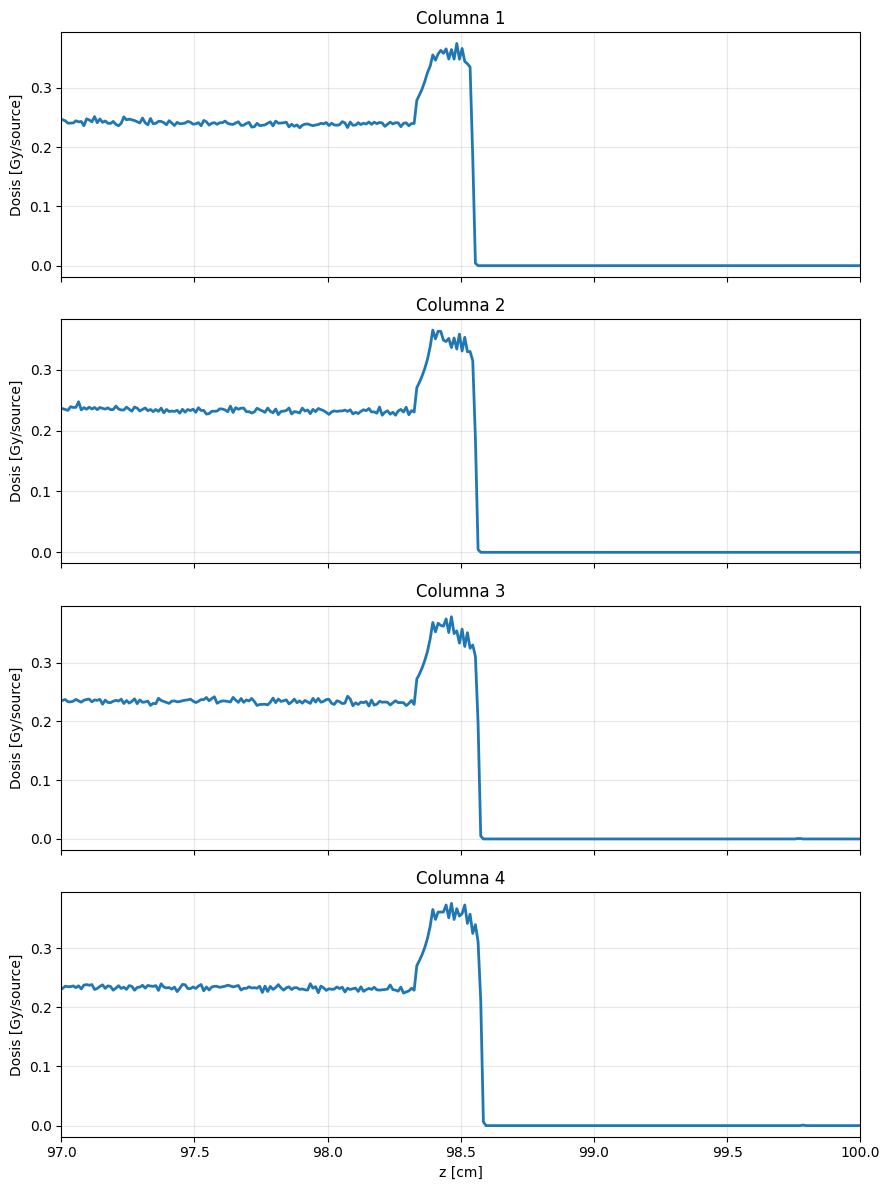

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(9, 12), sharex=True)

for ax, (nombre, archivo) in zip(axes, archivos.items()):
    z, dosis = leer_phits(archivo)

    ax.plot(z, dosis, linewidth=2)
    ax.set_xlim(97, 100)
    ax.set_ylabel("Dosis [Gy/source]")
    ax.set_title(nombre)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("z [cm]")

plt.tight_layout()
plt.show()

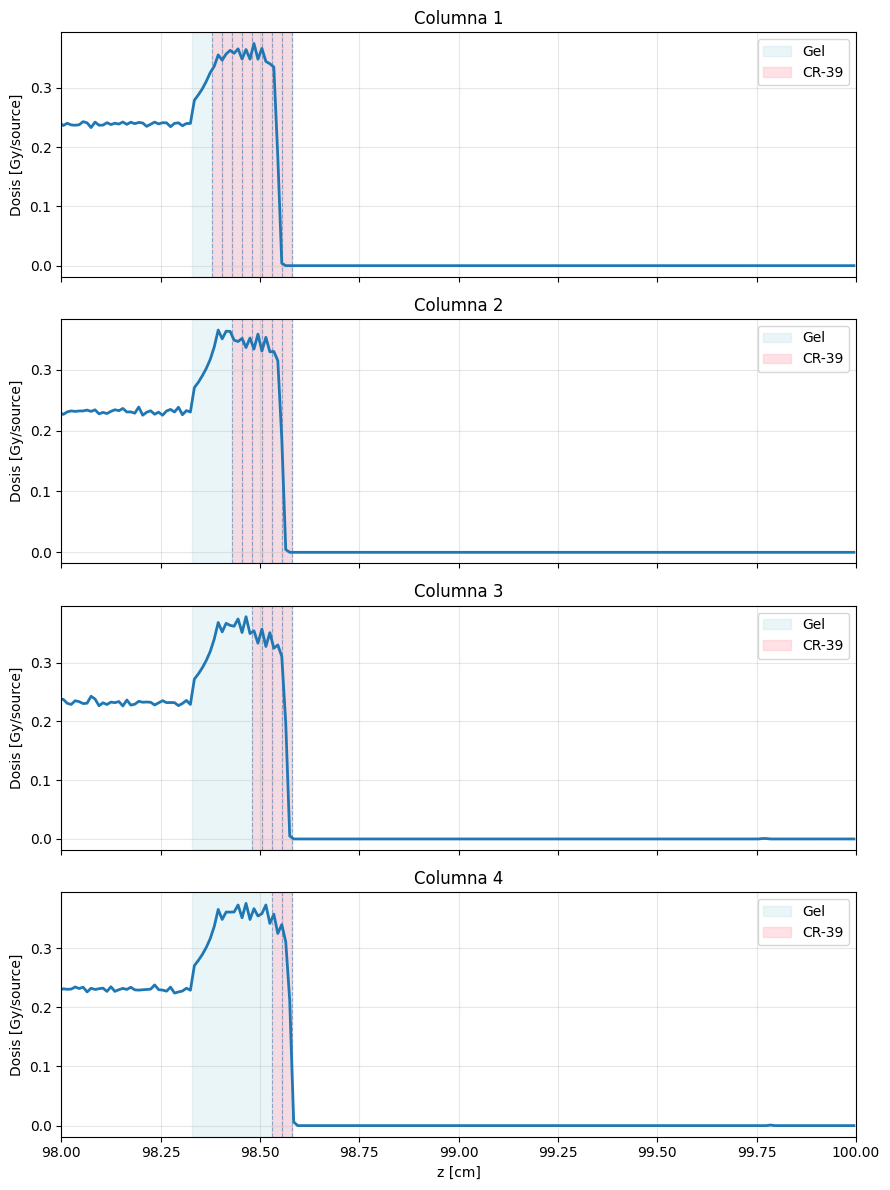

In [9]:
gel = (98.33, 98.58)

cr_por_columna = {
    "Columna 1": [
        (98.380, 98.405),
        (98.405, 98.430),
        (98.430, 98.455),
        (98.455, 98.480),
        (98.480, 98.505),
        (98.505, 98.530),
        (98.530, 98.555),
        (98.555, 98.580),
    ],
    "Columna 2": [
        (98.430, 98.455),
        (98.455, 98.480),
        (98.480, 98.505),
        (98.505, 98.530),
        (98.530, 98.555),
        (98.555, 98.580),
    ],
    "Columna 3": [
        (98.480, 98.505),
        (98.505, 98.530),
        (98.530, 98.555),
        (98.555, 98.580),
    ],
    "Columna 4": [
        (98.530, 98.555),
        (98.555, 98.580),
    ],
}

fig, axes = plt.subplots(4, 1, figsize=(9, 12), sharex=True)

for ax, (nombre, archivo) in zip(axes, archivos.items()):

    z, dosis = leer_phits(archivo)

    ax.plot(
        z,
        dosis,
        linewidth=2
    )

    ax.axvspan(
        gel[0],
        gel[1],
        color="lightblue",
        alpha=0.25,
        label="Gel"
    )

    for i, (zmin, zmax) in enumerate(cr_por_columna[nombre]):

        ax.axvspan(
            zmin,
            zmax,
            color="lightpink",
            alpha=0.40,
            label="CR-39" if i == 0 else None
        )

        ax.axvline(
            zmin,
            linestyle="--",
            linewidth=0.8,
            alpha=0.5
        )

    ax.axvline(
        cr_por_columna[nombre][-1][1],
        linestyle="--",
        linewidth=0.8,
        alpha=0.5
    )

    ax.set_xlim(98, 100)

    ax.set_ylabel("Dosis [Gy/source]")
    ax.set_title(nombre)

    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("z [cm]")

plt.tight_layout()
plt.show()

hice :


maxcas = 10000    → 10.000 historias por batch

maxbch = 5000     → máximo 5.000 batches


pero la simulacion llego a : 2068 batches , o sea al 41.4%